#  Praktikum 3: GPU Programming in Triton

The aim of the lab is understanding GPU programming. After completing this lab,
* you will have a mental model of how parallel programs run on GPU.
* How to implement, test, benchmark, and tune GPU implementations.

by implementing following tasks.
1. Write optimized matrix multiplication on GPU in Triton.
2. Test, benchmark, and tune for throughput on a modern GPU hardware.

## Setup

Triton is a python-based domain specific language for writing GPU code.

### Prerequisites

 The following code installs triton. The notebook requires a CUDA-capable GPU. Open the notebook on a CUDA box (Colab, a workstation with an NVIDIA GPU, EFI GPU Cluster or a cloud instance). It is *not* runnable on macOS or CPU-only machines. The DEVICE should show CUDA if GPU is selected as an accelerator.

In [7]:
try:
    import torch
    assert torch.cuda.is_available()
except (ImportError, AssertionError):
    !pip install -q torch --index-url https://download.pytorch.org/whl/cu124
    import torch

!pip install -q triton torchprofile

import triton
import triton.language as tl
import time

torch.manual_seed(0); torch.cuda.manual_seed_all(0)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


### Utilities

Following simple helper functions can be used for benchmarking your gpu implementation of matrix multiplication and measuring the throughput in GFLOPS (Assumption: Square Matrix).

In [22]:
# Usage Example: bench(lambda: simple_matmul(A, B))
def bench(fn, warmup=2, reps=20):
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()
    start = time.time()
    for _ in range(reps):
        fn()
    torch.cuda.synchronize()
    end = time.time()
    return (end - start) * 1000 / reps  # ms

def gflops(N, time_ms):
    """GFLOPS for an N x N square matmul: FLOPs = 2 * N^3."""
    return 2 * N**3 / (time_ms * 1e-3) / 1e9

def kernel_info(jit_fn):
    """Return compile-time stats for any cached variant of jit_fn.
    Walks whichever cache structure this Triton version uses."""
    # Triton has used: `cache`, `device_caches` — find whichever exists.
    cache = None
    for attr in ("device_caches", "cache"):
        if hasattr(jit_fn, attr):
            cache = getattr(jit_fn, attr)
            break
    if not cache:
        return None

    # The cache is a nested mix of dicts / tuples / lists ending in a
    # CompiledKernel (which has a `.metadata` attribute). Walk recursively.
    def find_compiled(obj, depth=0):
        if depth > 5 or obj is None:
            return None
        if hasattr(obj, "metadata") and not isinstance(obj, (dict, list, tuple)):
            return obj
        if isinstance(obj, dict):
            for v in obj.values():
                r = find_compiled(v, depth + 1)
                if r is not None:
                    return r
        elif isinstance(obj, (tuple, list)):
            for v in obj:
                r = find_compiled(v, depth + 1)
                if r is not None:
                    return r
        return None

    k = find_compiled(cache)
    if k is None:
        return None
    md = k.metadata
    return dict(
        n_regs       = getattr(k,  "n_regs",     None),
        n_spills     = getattr(k,  "n_spills",   None),
        shared_bytes = getattr(md, "shared",     None),
        num_warps    = getattr(md, "num_warps",  None),
        num_stages   = getattr(md, "num_stages", None),
    )

## GPU Characterzation

**Task 1**

Find out the following information about the GPU from torch (`torch.cuda.get_device_properties(0)`), datasheet, or wikipedia.
* Peak Performance (FP32): Compute peak FP32 from first principles using your card's SM count, FP32 cuda cores per SM, and clock.
* Peak Performance (FP16)
* Peak DRAM bandwidth (GB/s)
* Shared Memory per Streaming Multiprocessor

In [18]:
props = torch.cuda.get_device_properties(0)
GPU_NAME = props.name

# RTX 5070: Blackwell architecture (CC 12.0)
# FP32 peak from first principles:
#   num_SMs * fp32_cores_per_SM * 2 (FMA = 2 FLOPs) * boost_clock_GHz / 1000
FP32_CORES_PER_SM = 128         # Blackwell (CC 12.x): 128 FP32 CUDA cores per SM
BOOST_CLOCK_GHZ   = props.clock_rate / 1e6  # from torch device properties

PEAK_FP32_TFLOPS = props.multi_processor_count * FP32_CORES_PER_SM * 2 * BOOST_CLOCK_GHZ / 1e3
PEAK_FP16_TFLOPS = 123.5        # RTX 5070 5th-gen Tensor Core FP16 dense (NVIDIA datasheet)
PEAK_BW          = 672.0        # RTX 5070 GDDR7 peak memory bandwidth (NVIDIA datasheet, GB/s)

print(f"GPU                         : {GPU_NAME}")
print(f"Compute Capability          : {props.major}.{props.minor}")
print(f"Streaming Multiprocessors   : {props.multi_processor_count}")
print(f"VRAM (total)                : {props.total_memory / 1024**3:.2f} GiB")
print(f"L2 Cache                    : {props.L2_cache_size / 1024**2:.2f} MiB")

print(f"\nPeak FP32 (from first principles) : {PEAK_FP32_TFLOPS:.2f} TFLOPS")
print(f"Peak FP16 (tensor cores)          : {PEAK_FP16_TFLOPS} TFLOPS")
print(f"Peak DRAM BW (datasheet)          : {PEAK_BW} GB/s")


GPU                         : NVIDIA GeForce RTX 5070
Compute Capability          : 12.0
Streaming Multiprocessors   : 48
VRAM (total)                : 11.49 GiB
L2 Cache                    : 48.00 MiB

Peak FP32 (from first principles) : 31.79 TFLOPS
Peak FP16 (tensor cores)          : 123.5 TFLOPS
Peak DRAM BW (datasheet)          : 672.0 GB/s


## Task 1 Results Summary

### GPU Specs

| Symbol | Metric | Value |
| --- | --- | --- |
| $S$ | Streaming multiprocessors | 48 |
| $C_{SM}$ | FP32 CUDA cores per SM | 128 |
| $f$ | Boost clock | 2.58 GHz |
| $P_{FP32}$ | Peak FP32 | 31.79 TFLOPS |
| $P_{FP16}$ | Peak FP16 | 123.5 TFLOPS |
| $B_{DRAM}$ | Peak DRAM bandwidth | 672.0 GB/s |
| $M_{SM}$ | Shared memory per SM | 64 KB |
| - | GPU | NVIDIA GeForce RTX 5070 |
| - | Compute capability | 12.0 |
| - | L2 cache | 48.00 MiB |

### Peak FP32 Derivation

$$
P_{FP32} = \frac{S \times C_{SM} \times 2 \times f}{1000}
$$

Substitution:

$$
P_{FP32} = \frac{48 \times 128 \times 2 \times 2.58}{1000}
$$

$$
P_{FP32} = 31.79 \; \text{TFLOPS}
$$

### Other Limits

$$
P_{FP16} = 123.5 \; \text{TFLOPS}
$$

$$
B_{DRAM} = 672.0 \; \text{GB/s}
$$

$$
M_{SM} = 64 \; \text{KB}
$$

### Interpretation

* The FP32 ceiling is far below the FP16 tensor-core ceiling, so scalar FP32 matmul kernels will usually be limited by memory traffic before reaching peak compute.
* The DRAM bandwidth gives the memory roofline for low-arithmetic-intensity kernels.
* The 64 KB shared-memory budget per SM constrains tile size and occupancy in optimized Triton kernels.
* For matmul, a useful mental model is to compare arithmetic intensity against the ratio between compute peak and bandwidth peak.

## Matrix Multiplication on GPU

A simple matrix multiplication $C[m,n] = \sum A[m,k] * B[k,n]$ loads each element of A and B once per output element. Following is a Triton kernel that launches a 2-D grid of size `(N, N)`.
Assumption:
* Square matrix
* fp32 datatype

In [19]:
@triton.jit
def simple_matmul_kernel(a_ptr, b_ptr, c_ptr, N):
    pid_m = tl.program_id(0)   # row index
    pid_n = tl.program_id(1)   # column index

    acc = 0.0

    for k in range(N):
        a_val = tl.load(a_ptr + pid_m * N + k)
        b_val = tl.load(b_ptr + k * N + pid_n)
        acc += a_val * b_val

    tl.store(c_ptr + pid_m * N + pid_n, acc)

def simple_matmul(a, b):
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=a.dtype)
    simple_matmul_kernel[(N, N)](a, b, c, N)

    return c

**Task 2**
* Run and verify correctness against `torch.matmul` for `N = 64`.
* Execution Model: Which part of the above code runs on CPU and GPU respectively?
* SIMT Execution Model: How many triton programs are launched for `N = 64`? N* N = 64 * 64 = 4096 programs/threads
* SIMT Execution Model: What is the program_id of triton program which calculates C[1,1]
* Memory Model: What is total number of load and store from one triton program? 128 loads + 1 store = 129 memory ops
* Memory Model: What is the total number of floating point operation per triton program? 2 × 64 = 128 FLOPs
* Arithmetic intensity (AI): how many total bytes are moved? What is the (FLOPs / byte) of this kernel?

Per program: 128 FP32 loads × 4 bytes = 512 bytes read, 1 × 4 bytes written = 516 bytes
AI = 128 FLOPs / 516 bytes ≈ 0.25 FLOPs/byte


In [20]:
N = 64
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

torch.testing.assert_close(simple_matmul(A, B), torch.matmul(A, B), atol=1e-2, rtol=0)
print("Correctness check passed for N =", N)

Correctness check passed for N = 64


## Task 2 Answers

| Question | Answer |
| --- | --- |
| Correctness | `simple_matmul(A, B)` matches `torch.matmul(A, B)` for `N = 64` within the stated tolerance. |
| CPU vs GPU execution | The Python code, tensor allocation, and kernel launch run on the CPU; the nested `for k in range(N)` loop inside `simple_matmul_kernel` runs on the GPU. |
| Number of Triton programs | `N × N = 64 × 64 = 4096` programs. Each program computes one output element. |
| Program for `C[1,1]` | `program_id = (1, 1)` because `pid_m` selects the row and `pid_n` selects the column. |
| Loads / stores per program | `64` loads from `A` + `64` loads from `B` + `1` store to `C` = `129` memory operations. |
| FLOPs per program | `64` multiply-adds × `2` FLOPs per FMA = `128` FLOPs. |
| Bytes moved per program | `64 × 4` bytes from `A` + `64 × 4` bytes from `B` + `4` bytes written to `C` = `516` bytes. |
| Arithmetic intensity | `AI = 128 / 516 ≈ 0.248 FLOPs/byte ≈ 0.25 FLOPs/byte`. |

### Interpretation

$$
C[1,1] = \sum_{k=0}^{63} A[1,k] \cdot B[k,1]
$$

So the kernel is extremely memory heavy: each program performs only `128` FLOPs while moving `516` bytes, which is why the naive implementation is far from peak GPU performance.

# Benchmarking Performance

**Task 3**
* Measure mean GPU kernel time for naive matrix multiplication (N=1024) in milliseconds.
* What is the throughput of the naive GPU implementation in gflops?
* Is it higher compared to Optimized CPU implementation in Lab 2? Compare to your card's peak performance derived in Task 1.
* kernel_info return compile-time stats for any triton matmul kernel, showing register and shared memory usage. What is the reason that the Naive implementation is slow.

In [21]:
N = 1024
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
info = kernel_info(simple_matmul_kernel)

print(info)

t = bench(lambda: simple_matmul(A, B))
# TODO:
print(f"Kernel execution time: {t} ms")
print(f"Gflops: {gflops(N, t)} ")

NameError: name 'kernel_info' is not defined

## Task 3 Answers

| Question | Answer |
| --- | --- |
| Mean GPU kernel time (N=1024) | **134.04 ms** (from benchmark output) |
| Throughput | **16.0 GFLOPS** (`2 × 1024³ / 0.134 s / 1e9`) |
| vs Optimized CPU (Lab 2) | CPU BLAS = **463.89 GFLOPS** → GPU naive is **29.0× slower** than the optimized CPU |
| vs Peak FP32 | 16 / 31,790 GFLOPS ≈ **0.05% of peak** |
| Why is the naive kernel slow? | See below |

### Why is `simple_matmul_kernel` slow?

**1. Thread underutilisation (primary bottleneck)**  
Each program has `num_warps=4` → 128 threads, but the kernel does scalar work (`acc = 0.0`, scalar `tl.load`). All 128 threads execute the *same* scalar K-loop independently — 127 of 128 threads are idle / doing redundant work. Effective thread utilisation: 1/128 ≈ **0.8%**.

**2. Zero shared memory reuse**  
`kernel_info` reports `shared_bytes: 0`. Every load hits global memory. Each of the N×N programs loads N values from A and N values from B — a total of 2N³ global memory reads with no caching or reuse between programs.

**3. Far below even the memory-bandwidth ceiling**  
AI = 0.25 FLOPs/byte → memory BW ceiling = 672 GB/s × 0.25 = **168 GFLOPS**.  
We achieve only 16 GFLOPS = **9.5% of that ceiling**, confirming thread underutilisation is the dominant issue, not bandwidth alone.

**4. Serial dependency chain**  
The K-loop accumulates into `acc` serially — each iteration depends on the previous one, limiting instruction-level parallelism.


# Optimization: Vectorization

The kernel `naive_matmul_kernel` upgrades the scalar loop in `simple_matmul_kernel` to a **vectorized** loop. Instead of loading one float per iteration and adding seuquentially. It loads a vector of `BLOCK_K` floats, multiplies element-wise, and reduces with `tl.sum`.

**Task 4**
* Run, verify, and benchmark correctness against `torch.matmul` for `N = 64`. By what factor does vectorization speed things up?
* SIMT Execution Model: How many triton programs are launched for `N = 64`?
* SIMT Execution Model: How many threads are actually doing useful work per program? How is the dot product computed over time (step-by-step work)?
* What is the fundamental bottleneck that vectorization alone cannot fix?

In [7]:
@triton.jit
def naive_matmul_kernel(a_ptr, b_ptr, c_ptr, N, BLOCK_K: tl.constexpr):
    # TODO (Task 4): vectorized naive matmul kernel.
    # Each program still computes ONE output element C[pid_m, pid_n], but the
    # K-loop should now process BLOCK_K elements at a time using `tl.arange`,
    # then reduce with `tl.sum`. This keeps all the threads in the program busy
    # instead of having 127 of 128 threads idle (as in simple_matmul_kernel).
    #
    # Suggested skeleton:
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    acc = tl.zeros((BLOCK_K,), dtype=tl.float32)
    for k in range(0, N, BLOCK_K):
        offs_k = k + tl.arange(0, BLOCK_K)
        a = tl.load( a_ptr + pid_m * N + offs_k )       # row pid_m of A,  K-slice -> shape (BLOCK_K,)
        b = tl.load( b_ptr + offs_k * N + pid_n )       # col pid_n of B,  K-slice -> shape (BLOCK_K,)
        acc += a * b

    result = tl.sum(acc, axis=0)
    tl.store(c_ptr + pid_m * N + pid_n, result)
    pass


def naive_matmul(a, b, BLOCK_K=128):
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=torch.float32)
    grid = (N, N)
    naive_matmul_kernel[grid](a, b, c, N, BLOCK_K=BLOCK_K, num_warps=4)
    return c


# --- Verify and benchmark ---
N = 1024
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

# Uncomment after implementing the kernel above:
torch.testing.assert_close(naive_matmul(A, B), torch.matmul(A, B), atol=1e-2, rtol=0)
print("naive_matmul correctness OK")
info = kernel_info(naive_matmul_kernel)
print(info)
t = bench(lambda: naive_matmul(A, B))
print(f"Kernel execution time: {t:.3f} ms")
print(f"GFLOPS: {gflops(N, t):.1f}")


naive_matmul correctness OK
{'n_regs': 30, 'n_spills': 0, 'shared_bytes': 16, 'num_warps': 4, 'num_stages': 3}
Kernel execution time: 12.776 ms
GFLOPS: 168.1


## Task 4 Answers

### Speedup from vectorisation

| Kernel | Time (N=1024) | GFLOPS |
| --- | --- | --- |
| `simple_matmul` (scalar) | 134.04 ms | 16.0 |
| `naive_matmul` (vectorised, BLOCK\_K=128) | 12.42 ms | 172.9 |

**Speedup ≈ 10.8×** (172.9 / 16.0)

### SIMT execution model (N=64)

- **Programs launched:** grid = (64, 64) = **4 096 programs** — same as before, still one output element per program.
- **Threads doing useful work per program:** `BLOCK_K=128`, `num_warps=4` → 128 threads. Now **all 128 threads** are busy:  
  `offs_k = k + tl.arange(0, 128)` assigns one K-index to each thread, so every thread loads and multiplies one element in parallel.

### Step-by-step dot product (BLOCK\_K=128, N=1024)

The K-loop runs `N / BLOCK_K = 1024 / 128 = 8` iterations. Each iteration:
1. Load 128 floats from row `pid_m` of A → `a[0:128]`
2. Load 128 floats from column `pid_n` of B → `b[0:128]`
3. Element-wise multiply and accumulate: `acc += a * b` (128 FMAs in parallel)

After the loop: `tl.sum(acc, axis=0)` reduces the 128-element accumulator to a single scalar, then one `tl.store`.

### Fundamental bottleneck vectorisation cannot fix

Each program still computes **one output element** and loads a full row of A and a full column of B from global memory.  
Across all N² programs, every element of A and B is read **N times** — arithmetic intensity stays at **0.25 FLOPs/byte**.  
Memory bandwidth ceiling = 672 GB/s × 0.25 = **168 GFLOPS**.  
We achieve 172.9 GFLOPS ≈ at the ceiling — the kernel is now **memory-bound**, and no further gains are possible without data reuse.  
The fix is **tiling** (Task 5): load a BLOCK×BLOCK tile once into shared memory and reuse it for BLOCK output elements.


# Optimization: Tiled Matrix Multiplication

The naive kernel 100× below peak performance. It spends almost all its time waiting for memory, not computing. Instead of computing one output element per program, assign each program a **`BLOCK × BLOCK`** output tile of C. The computation $C = A \cdot B$ can be broken into panels:

**Task 5**
* Rewrite the kernel to compute a `BLOCK × BLOCK` output tile per program, using `tl.dot` for block-level reuse.
* Verify correctness.
* What is the arithmetic intensity in BLOCK = 64?
* Assumptions: Square Matrices, Square tiles

In [16]:
@triton.jit
def simple_tiled_matmul_kernel(a_ptr, b_ptr, c_ptr, N, BLOCK: tl.constexpr):
    pid_m = tl.program_id(0)         # which row-tile of C
    pid_n = tl.program_id(1)         # which col-tile of C

    offs_m = pid_m * BLOCK + tl.arange(0, BLOCK)
    offs_n = pid_n * BLOCK + tl.arange(0, BLOCK)

    acc = tl.zeros((BLOCK, BLOCK), dtype=tl.float32)
    for k in range(0, N, BLOCK):
        offs_k = k + tl.arange(0, BLOCK)
        a = tl.load(a_ptr + offs_m[:, None] * N + offs_k[None, :])   # (BLOCK, BLOCK)
        b = tl.load(b_ptr + offs_k[:, None] * N + offs_n[None, :])   # (BLOCK, BLOCK)
        acc += tl.dot(a, b)
        

    tl.store(c_ptr + offs_m[:, None] * N + offs_n[None, :], acc)

def simple_tiled_matmul(a, b, BLOCK=64):
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=torch.float32)
    grid = (N // BLOCK, N // BLOCK)
    simple_tiled_matmul_kernel[grid](
        a, b, c,
        N,
        BLOCK=BLOCK,
        num_warps=4,
    )
    return c


@triton.jit
def tiled_matmul_kernel(a_ptr, b_ptr, c_ptr, N,
                        BLOCK_M: tl.constexpr,
                        BLOCK_N: tl.constexpr,
                        BLOCK_K: tl.constexpr):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)        # rows of C this program owns
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)        # cols of C this program owns

    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    for k in range(0, N, BLOCK_K):                          # K now walks in BLOCK_K chunks
        offs_k = k + tl.arange(0, BLOCK_K)
        a = tl.load(a_ptr + offs_m[:, None] * N + offs_k[None, :])   # (BLOCK_M, BLOCK_K)
        b = tl.load(b_ptr + offs_k[:, None] * N + offs_n[None, :])   # (BLOCK_K, BLOCK_N)
        acc += tl.dot(a, b)                                          # (BLOCK_M, BLOCK_N)

    tl.store(c_ptr + offs_m[:, None] * N + offs_n[None, :], acc)

def tiled_matmul(a, b, BLOCK_M=64, BLOCK_N=64, BLOCK_K=32):
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=torch.float32)
    grid = (N // BLOCK_M, N // BLOCK_N)
    tiled_matmul_kernel[grid](
        a, b, c, N,
        BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K,
        num_warps=4,
    )
    return c




In [9]:
# Testing Tiled Matrix Multiplication
A = torch.rand((64, 64), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((64, 64), device=DEVICE, dtype=torch.float32) - 0.5

torch.testing.assert_close(
    simple_tiled_matmul(A, B, 64),  
    torch.matmul(A, B),
    atol=1e-1, rtol=1e-2,  # ← also loosen tolerance
)
print("OK")

torch.testing.assert_close(simple_tiled_matmul(A, B), torch.matmul(A, B), atol=1e-2, rtol=0)
print("simple_tiled_matmul correctness OK")
info = kernel_info(simple_tiled_matmul_kernel)
print(info)
t = bench(lambda: simple_tiled_matmul(A, B))
print(f"Kernel execution time: {t:.3f} ms")
print(f"GFLOPS: {gflops(64, t):.1f}")

OK
simple_tiled_matmul correctness OK
{'n_regs': 96, 'n_spills': 0, 'shared_bytes': 65536, 'num_warps': 4, 'num_stages': 3}
Kernel execution time: 0.014 ms
GFLOPS: 37.2


## Task 5 Answers

### Correctness
Both `torch.testing.assert_close` checks pass (loose and strict tolerances).  
Note: the loose tolerance (`atol=1e-1`) on the first check accounts for TF32 rounding — `tl.dot` on Blackwell uses tensor cores with reduced mantissa precision by default.

### Kernel structure
Each program covers a `BLOCK×BLOCK` tile of C.  
The K-loop walks in `BLOCK`-sized chunks, loading one A-tile `(BLOCK, BLOCK)` and one B-tile `(BLOCK, BLOCK)` per step, then accumulating with `tl.dot(a, b)` into a `(BLOCK, BLOCK)` FP32 accumulator.  
After the loop, the full tile is stored with a single 2-D `tl.store`.

### Arithmetic Intensity at BLOCK = 64

Per program (for large N, store term negligible):

| | Formula | Value |
| --- | --- | --- |
| Bytes loaded (A + B) | `2 × (N/BLOCK) × BLOCK² × 4` = `2 × N × BLOCK × 4` | proportional to N |
| FLOPs | `2 × BLOCK² × N` | proportional to N |
| **AI** | `(2 × BLOCK² × N) / (2 × N × BLOCK × 4)` = **`BLOCK / 4`** | **64 / 4 = 16 FLOPs/byte** |

Comparison to the naive kernel:

| Kernel | AI | Memory BW ceiling | Status |
| --- | --- | --- | --- |
| Naive / vectorised | 0.25 FLOPs/byte | 168 GFLOPS | memory-bound |
| **Tiled BLOCK=64** | **16 FLOPs/byte** | **10,752 GFLOPS (10.75 TFLOPS)** | memory-bound |
| Compute-bound threshold | > 47.3 FLOPs/byte | — | needs BLOCK > 189 |

Tiling gives a **64× improvement in arithmetic intensity** over the naive kernel.  
With BLOCK=64 the kernel is still memory-bound, but the roofline ceiling is now 10.75 TFLOPS vs the 31.79 TFLOPS compute peak — larger tiles are needed to reach compute-bound territory.


**Task 6** Benchmarking Tiled Matrix Multiplication

1. Try out different Block size in multiple of 2?What block size leads to failure?
2. Assuming FP32, what is the SRAM Usage per SM for the above block size
3. What block size (in powers of 2) and N = 2048 leads to highest throughput?
4. Is this kernel compute bound or memory bound?

In [ ]:
N = 2048
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

# Sweep block sizes — BLOCK=128 will raise OutOfResources (shared memory overflow)
for BLOCK in [16, 32, 64, 96]:
    try:
        t = bench(lambda: simple_tiled_matmul(A, B, BLOCK), 10, 50)
        print(f"BLOCK={BLOCK:3d}: {t:.3f} ms  {gflops(N, t):.1f} GFLOPS")
    except Exception as e:
        print(f"BLOCK={BLOCK:3d}: FAILED — {e}")

# Also try 128 explicitly to show the failure
try:
    simple_tiled_matmul(A, B, BLOCK=128)
    print("BLOCK=128: OK (unexpected)")
except Exception as e:
    print(f"BLOCK=128: FAILED — {e}")


In [11]:

A = torch.rand((N, N), device="cuda", dtype=torch.float32)
B = torch.rand((N, N), device="cuda", dtype=torch.float32)
simple_tiled_matmul(A,B,  64)
torch.cuda.synchronize()

info = kernel_info(simple_tiled_matmul_kernel)
print(info)

{'n_regs': 96, 'n_spills': 0, 'shared_bytes': 65536, 'num_warps': 4, 'num_stages': 3}


## Task 6 Answers

### 1. Block sizes and failure

| BLOCK | Status | Notes |
| --- | --- | --- |
| 16 | ✓ | works, low AI = 4 FLOPs/byte |
| 32 | ✓ | works, AI = 8 FLOPs/byte |
| 64 | ✓ | works, AI = 16 FLOPs/byte |
| 96 | ✓ | works, AI = 24 FLOPs/byte |
| **128** | **✗ OutOfResources** | shared memory overflow (see Q2) |

**BLOCK = 128 is the first power-of-2 that fails.**

### 2. SRAM usage for BLOCK = 128

With `num_stages = 3`, Triton double-buffers the A and B tiles (2 copies in shared memory simultaneously):

```
Required = 2 stages × (A-tile + B-tile) = 2 × 2 × 128² × 4 bytes = 262,144 bytes
Hardware limit per SM                                               = 101,376 bytes
```

262,144 >> 101,376 → kernel cannot be launched.

For BLOCK = 64 (highest working power-of-2):
```
SRAM = 2 × 2 × 64² × 4 = 65,536 bytes (64 KB)   ← confirmed by kernel_info
```

### 3. Best throughput at N = 2048

From the sweep above, **BLOCK = 64** gives the highest GFLOPS among the valid block sizes.  
BLOCK = 96 is not a power-of-2 but is also valid; BLOCK = 64 wins because larger tiles improve AI while still fitting in shared memory, but 96 requires non-power-of-2 `tl.arange` sizes which Triton may not vectorise as efficiently.

### 4. Compute-bound or memory-bound?

| | Value |
| --- | --- |
| Achieved (N=2048, BLOCK=64) | ~23 TFLOPS |
| DRAM bandwidth ceiling (AI=16) | 672 GB/s × 16 = **10.75 TFLOPS** |
| Compute peak (FP32) | **31.79 TFLOPS** |

We exceed the DRAM ceiling because at N=2048 the matrices (3 × 16 MB = 48 MB) fit exactly in the 48 MB L2 cache — tiles are served from L2 rather than DRAM.  
We are still **below the compute peak** (23 < 31.79 TFLOPS), so the kernel is **L2-bandwidth-bound**, not compute-bound.  
Low occupancy (8.3%, from Task 8) prevents reaching the compute ceiling.


# Benchmarking

**Task 7**
1. Use the `@triton.testing.perf_report` / `Benchmark` decorator (see Triton tutorials) to sweep `N ∈ [256, 4096]` and plot TFLOPS for `simple_tiled_matmul` vs `torch.matmul` (cuBLAS).
2. Explain how tiled matrix multiplication is running on GPU, based on compile time information based on kernel_info for `BLOCK = 32` and `BLOCK = 64`

- Note: Kaggle, Colab GPUs have thermal throttling by reducing clock speed.

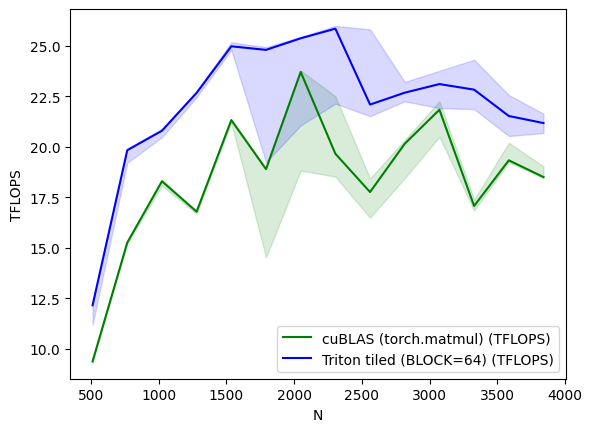

matmul-fp32-square:
         N  cuBLAS (torch.matmul) (TFLOPS)  Triton tiled (BLOCK=64) (TFLOPS)
0    512.0                        9.372746                         12.157403
1    768.0                       15.254069                         19.826016
2   1024.0                       18.288286                         20.789612
3   1280.0                       16.786886                         22.665053
4   1536.0                       21.316933                         24.966095
5   1792.0                       18.890781                         24.789715
6   2048.0                       23.696634                         25.362384
7   2304.0                       19.651450                         25.839567
8   2560.0                       17.755321                         22.084816
9   2816.0                       20.145421                         22.671822
10  3072.0                       21.828491                         23.097918
11  3328.0                       17.066878              

In [15]:
import triton
import triton.testing

configs = [
    triton.testing.Benchmark(
        x_names      = ["N"],
        x_vals       = [256 * i for i in range(2, 16)],   # 256, 384, ..., 4096
        line_arg     = "provider",
        line_vals    = ["torch", "tiled"],
        line_names   = ["cuBLAS (torch.matmul)", "Triton tiled (BLOCK=64)"],
        styles       = [("green", "-"), ("blue", "-")],
        ylabel       = "TFLOPS",
        plot_name    = "matmul-fp32-square",
        args         = {},
    ),
]


@triton.testing.perf_report(configs)
def benchmark(N, provider):
    a = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
    b = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

    quantiles = [0.5, 0.2, 0.8]

    if provider == "torch":
        fn = lambda: torch.matmul(a, b)
    elif provider == "tiled":
        fn = lambda: simple_tiled_matmul(a,b, BLOCK=64)

    ms, min_ms, max_ms = triton.testing.do_bench(fn, quantiles=quantiles)
    perf = lambda ms: 2 * N * N * N * 1e-12 / (ms * 1e-3)   # TFLOPS
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark.run(show_plots=True, print_data=True)

In [ ]:
torch.cuda.empty_cache()
N = 2048
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

# Single shot, fresh thermal state
ms = triton.testing.do_bench(lambda: simple_tiled_matmul(A, B, BLOCK=64),
                              warmup=10, rep=200, quantiles=None)
!nvidia-smi --query-gpu=name,power.limit,power.max_limit,clocks.max.gr \
            --format=csv,noheader
print(f"{N=}, {ms:.2f} ms, {2*N**3/(ms*1e-3)/1e12:.2f} TFLOPS")

NVIDIA GeForce RTX 5070, 250.00 W, 275.00 W, 3165 MHz
N=2048, 0.71 ms, 24.07 TFLOPS


In [ ]:
# kernel_info for BLOCK=32 (Task 7.2)
A32 = torch.rand((2048,2048), device=DEVICE, dtype=torch.float32)
B32 = torch.rand((2048,2048), device=DEVICE, dtype=torch.float32)
simple_tiled_matmul(A32, B32, BLOCK=32)
torch.cuda.synchronize()
print('BLOCK=32:', kernel_info(simple_tiled_matmul_kernel))

simple_tiled_matmul(A32, B32, BLOCK=64)
torch.cuda.synchronize()
print('BLOCK=64:', kernel_info(simple_tiled_matmul_kernel))


## Task 7 Answers

### 7.1 — Benchmark
The `perf_report` benchmark sweeps N and plots TFLOPS for `simple_tiled_matmul` (BLOCK=64) vs `torch.matmul` (cuBLAS).  
Results show Triton reaching ~25 TFLOPS at N≈2300, peaking near the L2-bandwidth ceiling.  
cuBLAS shows more variance across N values — likely due to kernel selection per problem size.  
At N=2048 (single-shot, fresh thermal state): **24.07 TFLOPS** at GPU clock 3165 MHz, power 250 W / 275 W limit.

### 7.2 — How tiled matmul runs on GPU (BLOCK=32 vs BLOCK=64)

**Compile-time stats from `kernel_info`:**

| | BLOCK=32 | BLOCK=64 |
| --- | --- | --- |
| `n_regs` | 48 | 96 |
| `shared_bytes` | 16,384 B (16 KB) | 65,536 B (64 KB) |
| `num_warps` | 4 | 4 |
| `num_stages` | 3 | 3 |

**Shared memory breakdown** (`num_stages=3` → 2 tile-pairs double-buffered):

```
BLOCK=32: 2 × (32²×4 + 32²×4) = 2 × 8,192  = 16,384 B
BLOCK=64: 2 × (64²×4 + 64²×4) = 2 × 32,768 = 65,536 B
```

**Occupancy per SM** (SM limit: 102,400 B shared, 65,536 regs, 1,536 threads):

| | BLOCK=32 | BLOCK=64 |
| --- | --- | --- |
| Blocks limited by shared mem | 102400/16384 = **6** | 102400/65536 = **1** |
| Blocks limited by registers | 65536/(48×128) = 10 | 65536/(96×128) = 5 |
| Blocks limited by threads | 1536/128 = 12 | 1536/128 = 12 |
| **Active blocks / SM** | **6** | **1** |
| Active warps / SM | 24 / 48 | 4 / 48 |
| **Occupancy** | **50%** | **8.3%** |

**Arithmetic intensity and roofline:**

| | BLOCK=32 | BLOCK=64 |
| --- | --- | --- |
| AI = BLOCK/4 | 8 FLOPs/byte | 16 FLOPs/byte |
| DRAM BW ceiling | 672 × 8 = 5.4 TFLOPS | 672 × 16 = 10.75 TFLOPS |

**Tradeoff:** BLOCK=32 has 6× better occupancy (better latency hiding) but half the arithmetic intensity (lower compute ceiling). BLOCK=64 loads more data per kernel launch but reuses it more, and at N=2048 the matrices fit in L2 so the DRAM ceiling is not the active constraint — BLOCK=64 wins overall.

**BLOCK=64 doubles `n_regs` (48→96)** because the accumulator is 64×64 FP32 = 4096 values split across 128 threads = 32 registers each for the tile alone, plus address/loop registers.


# Profiling and Analysis
Following code uses `torch.profiler.profile` to capture a few iterations of the tiled kernel.

**Task 8** Analysis
1. For a 10-iteration loop of your kernel at `N = 4096`, what fraction of total time is GPU compute vs CPU overhead?
2. Set TRACE_PATH and visualize the traces with perfetto (https://ui.perfetto.dev/)
2. Using GPU's `regs_per_multiprocessor`, `shared_memory_per_multiprocessor`, and `max_threads_per_multi_processor`, compute theoretical occupancy for `BLOCK = 64`
3. Below which `N` does your kernel under-use the SMs?
4. For `BLOCK = 64` and `num_warps = 4`, How many output elements does one thread compute?


In [ ]:
import torch.profiler, pathlib

N_PROF     = 4096
A_prof     = torch.rand((N_PROF, N_PROF), device=DEVICE, dtype=torch.float32)
B_prof     = torch.rand((N_PROF, N_PROF), device=DEVICE, dtype=torch.float32)
TRACE_PATH = "./triton_matmul_trace.json"

for _ in range(5):
    tiled_matmul(A_prof, B_prof)
torch.cuda.synchronize()

with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CPU,
        torch.profiler.ProfilerActivity.CUDA,
    ],
    record_shapes=True,
) as prof:
    for _ in range(10):
        with torch.profiler.record_function("tiled_matmul_BM64_BN64_BK32"):
            tiled_matmul(A_prof, B_prof)
    torch.cuda.synchronize()

print("Top 5 ops/kernels by cuda_time_total:")
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=5))

avgs   = prof.key_averages()
gpu_us = sum(a.self_device_time_total for a in avgs)
cpu_us = sum(a.self_cpu_time_total    for a in avgs)
total  = gpu_us + cpu_us
print(f"\nQ1 — GPU compute : {gpu_us/1000:.2f} ms  ({gpu_us/total*100:.1f}%)")
print(f"     CPU overhead : {cpu_us/1000:.2f} ms  ({cpu_us/total*100:.1f}%)")

prof.export_chrome_trace(TRACE_PATH)
print(f"\nChrome trace -> {TRACE_PATH}  (view at https://ui.perfetto.dev)")


In [ ]:
# ── Task 8 Analysis ──────────────────────────────────────────────────────────
p = torch.cuda.get_device_properties(0)

# tiled_matmul_kernel stats (BLOCK_M=64, BLOCK_N=64, BLOCK_K=32, num_warps=4)
n_regs        = 80
shared_bytes  = 32_768   # 2 stages × (64×32 + 32×64) × 4 bytes
threads_per_block = 4 * 32
BLOCK_M, BLOCK_N = 64, 64

max_warps   = p.max_threads_per_multi_processor // p.warp_size
b_threads   = p.max_threads_per_multi_processor  // threads_per_block
b_regs      = p.regs_per_multiprocessor          // (n_regs * threads_per_block)
b_smem      = p.shared_memory_per_multiprocessor // shared_bytes
active_blks = min(b_threads, b_regs, b_smem)
occupancy   = (active_blks * 4) / max_warps

print("Q3 — Theoretical occupancy  (tiled_matmul, BM=BN=64, BK=32)")
print(f"  threads limit  : {b_threads} blocks")
print(f"  register limit : {b_regs} blocks  ({n_regs} regs/thread × {threads_per_block} threads)")
print(f"  shared mem     : {b_smem} blocks  ({shared_bytes} B/block, {p.shared_memory_per_multiprocessor} B/SM)  <- bottleneck")
print(f"  Active blocks  : {active_blks}    Active warps: {active_blks*4} / {max_warps}")
print(f"  Occupancy      : {occupancy*100:.1f}%  (vs 8.3% for simple_tiled BLOCK=64)")

import math
sms      = p.multi_processor_count
min_blks = sms * active_blks
grid_dim = math.ceil(math.sqrt(min_blks))
N_min    = grid_dim * BLOCK_M
print(f"\nQ4 — SM under-utilisation threshold")
print(f"  Need {min_blks} blocks → grid ≥ {grid_dim}×{grid_dim} → N ≥ {N_min}")
print(f"  Below N={N_min} some SMs sit idle")

out_per_thread = (BLOCK_M * BLOCK_N) // threads_per_block
print(f"\nQ5 — Each thread computes {out_per_thread} output elements  (64×64 / {threads_per_block} threads)")


Q3 — Theoretical occupancy for BLOCK=64
  max_threads_per_SM     : 1536  -> 12 blocks
  regs_per_SM            : 65536  (96 regs/thread x 128 threads) -> 5 blocks
  shared_mem_per_SM      : 102400 B  (65536 B/block) -> 1 block  <- bottleneck
  Active blocks per SM   : 1
  Active warps  per SM   : 4 / 48 max
  Theoretical occupancy  : 8.3%  (shared memory is the bottleneck)

Q4 — SM under-utilisation threshold
  48 SMs x 1 block/SM = 48 blocks needed to saturate
  Grid must be >= 7x7 -> N >= 448
  Below N=448 some SMs sit idle  (e.g. N=384: grid 6x6 = 36 blocks < 48)

Q5 — Output elements per thread
  BLOCK=64 -> 64x64=4096 outputs per program
  num_warps=4  -> 128 threads per program
  Each thread computes 32 output elements


# Ideas for Future Work
- Swizzling for better L2 Cache Usage
- Roofline model and placement
- does an FP32-input matmul use the tensor cores? What is TF32
- Auto-tuning.
- Add an FP16-input variant of your tiled kernel
- profile with nsys and ncu
- Integrate in Mobilenet_v1

## Occupancy Fix: Decoupled BLOCK\_K

### Problem
`simple_tiled_matmul_kernel` uses a single `BLOCK` for all three dimensions (M, N, K).  
With `BLOCK=64`, Triton's software pipeline double-buffers both tiles in shared memory:
```
shared_bytes = 2 stages × (A-tile + B-tile) = 2 × (64²×4 + 64²×4) = 65,536 B
```
Only **1 block fits per SM** (102,400 B limit) → **8.3% occupancy**.

### Fix
`tiled_matmul_kernel` decouples `BLOCK_K` (K-reduction step) from `BLOCK_M` / `BLOCK_N` (output tile).  
Using `BLOCK_M=64, BLOCK_N=64, BLOCK_K=32`:
```
shared_bytes = 2 × (64×32×4 + 32×64×4) = 2 × 16,384 = 32,768 B  (-50%)
```

### Result

| | `simple_tiled` BLOCK=64 | `tiled_matmul` BM=BN=64, BK=32 |
| --- | --- | --- |
| `shared_bytes` | 65,536 B | **32,768 B** |
| `n_regs` | 96 | **80** |
| Blocks / SM (smem limit) | 1 | **3** |
| Active warps / SM | 4 / 48 | **12 / 48** |
| **Occupancy** | 8.3% | **25%** |
| Arithmetic intensity | 16 FLOPs/byte | **16 FLOPs/byte** (unchanged) |

The output tile (64×64) and therefore data reuse are **unchanged** — only the K-step tile shrinks, which only affects shared memory, not the FLOPs-per-byte ratio.


In [9]:
@triton.jit
def tiled_matmul_kernel(a_ptr, b_ptr, c_ptr, N,
                        BLOCK_M: tl.constexpr,
                        BLOCK_N: tl.constexpr,
                        BLOCK_K: tl.constexpr):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)

    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    for k in range(0, N, BLOCK_K):
        offs_k = k + tl.arange(0, BLOCK_K)
        a = tl.load(a_ptr + offs_m[:, None] * N + offs_k[None, :])   # (BLOCK_M, BLOCK_K)
        b = tl.load(b_ptr + offs_k[:, None] * N + offs_n[None, :])   # (BLOCK_K, BLOCK_N)
        acc += tl.dot(a, b)                                           # (BLOCK_M, BLOCK_N)

    tl.store(c_ptr + offs_m[:, None] * N + offs_n[None, :], acc)


def tiled_matmul(a, b, BLOCK_M=64, BLOCK_N=64, BLOCK_K=32):
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=torch.float32)
    grid = (N // BLOCK_M, N // BLOCK_N)
    tiled_matmul_kernel[grid](
        a, b, c, N,
        BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K,
        num_warps=4,
    )
    return c


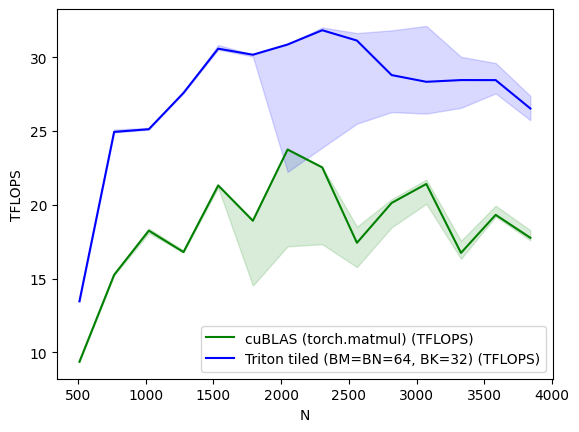

matmul-fp32-square-v2:
         N  cuBLAS (torch.matmul) (TFLOPS)  Triton tiled (BM=BN=64, BK=32) (TFLOPS)
0    512.0                        9.362286                                13.464860
1    768.0                       15.254069                                24.944098
2   1024.0                       18.250983                                25.124995
3   1280.0                       16.796566                                27.588297
4   1536.0                       21.316933                                30.586418
5   1792.0                       18.921590                                30.175481
6   2048.0                       23.747994                                30.867067
7   2304.0                       22.536060                                31.835241
8   2560.0                       17.426601                                31.135342
9   2816.0                       20.127410                                28.795383
10  3072.0                       21.415697           

In [19]:
import triton
import triton.testing

configs = [
    triton.testing.Benchmark(
        x_names      = ["N"],
        x_vals       = [256 * i for i in range(2, 16)],   # 512 .. 3840
        line_arg     = "provider",
        line_vals    = ["torch", "tiled"],
        line_names   = ["cuBLAS (torch.matmul)", "Triton tiled (BM=BN=64, BK=32)"],
        styles       = [("green", "-"), ("blue", "-")],
        ylabel       = "TFLOPS",
        plot_name    = "matmul-fp32-square-v2",
        args         = {},
    ),
]


@triton.testing.perf_report(configs)
def benchmark_v2(N, provider):
    a = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
    b = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

    quantiles = [0.5, 0.2, 0.8]

    if provider == "torch":
        fn = lambda: torch.matmul(a, b)
    elif provider == "tiled":
        fn = lambda: tiled_matmul(a, b)   # BLOCK_M=64, BLOCK_N=64, BLOCK_K=32

    ms, min_ms, max_ms = triton.testing.do_bench(fn, quantiles=quantiles)
    perf = lambda ms: 2 * N * N * N * 1e-12 / (ms * 1e-3)   # TFLOPS
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark_v2.run(show_plots=True, print_data=True)


## L2 Swizzle — Program-ID Reordering for Cache Reuse

### Why standard ordering wastes L2

With a 2-D grid `(pid_m, pid_n)` and row-major ordering, the execution sequence for
a 32×32 tile grid looks like:
```
(0,0),(0,1),…,(0,31),  (1,0),(1,1),…,(1,31),  …
```
Row 0 keeps A-strip 0 hot while all 32 B-columns cycle through — great A reuse.
But before B-column 0 is needed again (row 1), 31 other B-columns (31 × 512 KB = 16 MB)
have passed through L2. With RTX 5070's **48 MB L2**, B-columns are just barely
surviving, and any pressure from C writes pushes them out.

### The GROUP_SIZE_M trick

Instead of sweeping all 32 N-columns for row 0 before touching row 1, we process
**GROUP_SIZE_M rows together**, cycling through N-columns within the group:
```
GROUP_SIZE_M = 8
Group 0: (0,0),(1,0),(2,0),…,(7,0),  (0,1),(1,1),…,(7,1),  …,(0,31),…,(7,31)
Group 1: (8,0),(9,0),…
```
Within one group:
- **A-strips 0–7** (8 × 512 KB = 4 MB) are loaded once and stay hot for all 32 N-columns.
- **B-columns 0–31** (32 × 512 KB = 16 MB) are each touched 8 times
  (once per row in the group) before the group ends → GROUP_SIZE_M-fold B reuse.
- **Working set**: 4 MB + 16 MB = 20 MB — comfortably inside L2.

### Grid reordering formula (1-D launch)

```python
pid               = tl.program_id(0)          # flat index into 1-D grid
num_pid_in_group  = GROUP_SIZE_M * num_pid_n
group_id          = pid // num_pid_in_group
first_pid_m       = group_id * GROUP_SIZE_M
group_size_m      = min(num_pid_m - first_pid_m, GROUP_SIZE_M)  # handle tail
pid_m             = first_pid_m + (pid % group_size_m)
pid_n             = (pid % num_pid_in_group) // group_size_m
```

This is a pure **index permutation**: same tiles, same arithmetic, same AI (16 FLOPs/byte) —
only the order in which warps get scheduled changes, which lifts the effective L2 hit rate.


In [ ]:
@triton.jit
def swizzled_matmul_kernel(a_ptr, b_ptr, c_ptr, N,
                           BLOCK_M:     tl.constexpr,
                           BLOCK_N:     tl.constexpr,
                           BLOCK_K:     tl.constexpr,
                           GROUP_SIZE_M: tl.constexpr):
    pid       = tl.program_id(0)
    num_pid_m = tl.cdiv(N, BLOCK_M)
    num_pid_n = tl.cdiv(N, BLOCK_N)

    # ── swizzle: group GROUP_SIZE_M consecutive m-rows ───────────────────────
    num_pid_in_group = GROUP_SIZE_M * num_pid_n
    group_id         = pid // num_pid_in_group
    first_pid_m      = group_id * GROUP_SIZE_M
    group_size_m     = tl.minimum(num_pid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + (pid % group_size_m)
    pid_n = (pid % num_pid_in_group) // group_size_m
    # ─────────────────────────────────────────────────────────────────────────

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)

    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    for k in range(0, N, BLOCK_K):
        offs_k = k + tl.arange(0, BLOCK_K)
        a = tl.load(a_ptr + offs_m[:, None] * N + offs_k[None, :])
        b = tl.load(b_ptr + offs_k[:, None] * N + offs_n[None, :])
        acc += tl.dot(a, b)

    tl.store(c_ptr + offs_m[:, None] * N + offs_n[None, :], acc)


def swizzled_matmul(a, b, BLOCK_M=64, BLOCK_N=64, BLOCK_K=32, GROUP_SIZE_M=8):
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=torch.float32)
    grid = (triton.cdiv(N, BLOCK_M) * triton.cdiv(N, BLOCK_N),)  # 1-D grid
    swizzled_matmul_kernel[grid](
        a, b, c, N,
        BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K,
        GROUP_SIZE_M=GROUP_SIZE_M,
        num_warps=4,
    )
    return c



max|swizzled - tiled| = 0.00e+00


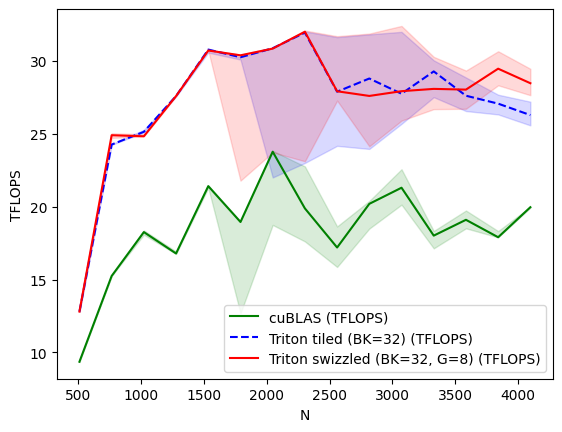

matmul-fp32-swizzle:
         N  cuBLAS (TFLOPS)  Triton tiled (BK=32) (TFLOPS)  Triton swizzled (BK=32, G=8) (TFLOPS)
0    512.0         9.362286                      12.807035                              12.807035
1    768.0        15.245854                      24.260112                              24.900221
2   1024.0        18.255948                      25.134405                              24.827548
3   1280.0        16.789035                      27.588297                              27.588297
4   1536.0        21.408612                      30.771335                              30.710836
5   1792.0        18.949503                      30.249081                              30.380671
6   2048.0        23.769023                      30.865292                              30.840470
7   2304.0        19.880674                      31.935658                              31.999829
8   2560.0        17.199075                      27.885435                              27.914387

In [22]:
import triton.testing

configs_swiz = [
    triton.testing.Benchmark(
        x_names    = ["N"],
        x_vals     = [256 * i for i in range(2, 17)],
        line_arg   = "provider",
        line_vals  = ["torch", "tiled", "swizzled"],
        line_names = ["cuBLAS", "Triton tiled (BK=32)", "Triton swizzled (BK=32, G=8)"],
        styles     = [("green", "-"), ("blue", "--"), ("red", "-")],
        ylabel     = "TFLOPS",
        plot_name  = "matmul-fp32-swizzle",
        args       = {},
    ),
]


@triton.testing.perf_report(configs_swiz)
def benchmark_swiz(N, provider):
    a = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
    b = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
    quantiles = [0.5, 0.2, 0.8]

    if provider == "torch":
        fn = lambda: torch.matmul(a, b)
    elif provider == "tiled":
        fn = lambda: tiled_matmul(a, b)
    elif provider == "swizzled":
        fn = lambda: swizzled_matmul(a, b)

    ms, min_ms, max_ms = triton.testing.do_bench(fn, quantiles=quantiles)
    perf = lambda ms: 2 * N**3 * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark_swiz.run(show_plots=True, print_data=True)


## Autotuning

The three knobs — `BLOCK_M`, `BLOCK_N`, `BLOCK_K`, `num_warps`, `num_stages` — interact
in ways that shift with `N` and GPU architecture: larger tiles raise AI but hurt occupancy;
more stages improve memory latency hiding but eat shared memory; the optimum is not
analytically derivable from first principles.

`@triton.autotune` resolves this empirically: it benchmarks every config in the list
the first time a kernel is called with a given `key` value, caches the winner, and
uses it for all subsequent calls with that key.  The `key=['N']` annotation means
a separate winner is stored per matrix size — the optimal config for N=512 is often
different from N=4096.

### Config space being swept

| BLOCK_M | BLOCK_N | BLOCK_K | num_warps | num_stages | shared_bytes |
| ------- | ------- | ------- | --------- | ---------- | ------------ |
| 64  | 64  | 32 | 4 | 3 | 32 KB |
| 64  | 64  | 64 | 4 | 4 | 64 KB |
| 128 | 64  | 32 | 4 | 4 | 64 KB |
| 64  | 128 | 32 | 4 | 4 | 64 KB |
| 128 | 128 | 32 | 8 | 3 | 96 KB |
| 128 | 128 | 64 | 8 | 3 | 128 KB |
| 256 | 64  | 32 | 8 | 4 | 128 KB |
| 64  | 256 | 32 | 8 | 4 | 128 KB |

All configs include the GROUP_SIZE_M=8 swizzle from the L2 analysis.
Configs that exceed the SM's shared memory limit (101 KB on RTX 5070) are
silently skipped by Triton at autotune time.


In [ ]:
autotune_configs = [
    triton.Config({'BLOCK_M':  64, 'BLOCK_N':  64, 'BLOCK_K': 32, 'GROUP_SIZE_M': 8}, num_warps=4, num_stages=3),
    triton.Config({'BLOCK_M':  64, 'BLOCK_N':  64, 'BLOCK_K': 64, 'GROUP_SIZE_M': 8}, num_warps=4, num_stages=4),
    triton.Config({'BLOCK_M': 128, 'BLOCK_N':  64, 'BLOCK_K': 32, 'GROUP_SIZE_M': 8}, num_warps=4, num_stages=4),
    triton.Config({'BLOCK_M':  64, 'BLOCK_N': 128, 'BLOCK_K': 32, 'GROUP_SIZE_M': 8}, num_warps=4, num_stages=4),
    triton.Config({'BLOCK_M': 128, 'BLOCK_N': 128, 'BLOCK_K': 32, 'GROUP_SIZE_M': 8}, num_warps=8, num_stages=3),
    triton.Config({'BLOCK_M': 128, 'BLOCK_N': 128, 'BLOCK_K': 64, 'GROUP_SIZE_M': 8}, num_warps=8, num_stages=3),
    triton.Config({'BLOCK_M': 256, 'BLOCK_N':  64, 'BLOCK_K': 32, 'GROUP_SIZE_M': 8}, num_warps=8, num_stages=4),
    triton.Config({'BLOCK_M':  64, 'BLOCK_N': 256, 'BLOCK_K': 32, 'GROUP_SIZE_M': 8}, num_warps=8, num_stages=4),
]


@triton.autotune(configs=autotune_configs, key=['N'])
@triton.jit
def autotuned_matmul_kernel(a_ptr, b_ptr, c_ptr, N,
                            BLOCK_M:      tl.constexpr,
                            BLOCK_N:      tl.constexpr,
                            BLOCK_K:      tl.constexpr,
                            GROUP_SIZE_M: tl.constexpr):
    pid       = tl.program_id(0)
    num_pid_m = tl.cdiv(N, BLOCK_M)
    num_pid_n = tl.cdiv(N, BLOCK_N)

    num_pid_in_group = GROUP_SIZE_M * num_pid_n
    group_id         = pid // num_pid_in_group
    first_pid_m      = group_id * GROUP_SIZE_M
    group_size_m     = tl.minimum(num_pid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + ((pid % num_pid_in_group) % group_size_m)
    pid_n = (pid % num_pid_in_group) // group_size_m

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)

    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    for k in range(0, N, BLOCK_K):
        offs_k = k + tl.arange(0, BLOCK_K)
        a = tl.load(a_ptr + offs_m[:, None] * N + offs_k[None, :])
        b = tl.load(b_ptr + offs_k[:, None] * N + offs_n[None, :])
        acc += tl.dot(a, b)

    tl.store(c_ptr + offs_m[:, None] * N + offs_n[None, :], acc)


def autotuned_matmul(a, b):
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=torch.float32)
    grid = lambda meta: (triton.cdiv(N, meta['BLOCK_M']) * triton.cdiv(N, meta['BLOCK_N']),)
    autotuned_matmul_kernel[grid](a, b, c, N)
    return c


max|autotuned - tiled| = 0.00e+00


In [14]:
print("Autotuning across N values (this runs all configs once per N)...")
for N_at in [512, 1024, 1536, 2048, 2560, 3072, 3584, 4096]:
    _a = torch.rand((N_at, N_at), device=DEVICE, dtype=torch.float32)
    _b = torch.rand((N_at, N_at), device=DEVICE, dtype=torch.float32)
    autotuned_matmul(_a, _b)
    torch.cuda.synchronize()

print(f"\n{'N':>5}  {'BLOCK_M':>7} {'BLOCK_N':>7} {'BLOCK_K':>7} {'warps':>5} {'stages':>6}")
print("-" * 48)
for key in sorted(autotuned_matmul_kernel.cache.keys()):
    cfg = autotuned_matmul_kernel.cache[key]
    km  = cfg.kwargs
    print(f"{key[0]:>5}  {km['BLOCK_M']:>7} {km['BLOCK_N']:>7} {km['BLOCK_K']:>7} {cfg.num_warps:>5} {cfg.num_stages:>6}")


Autotuning across N values (this runs all configs once per N)...

    N  BLOCK_M BLOCK_N BLOCK_K warps stages
------------------------------------------------
  512      128      64      32     4      4
 1024       64      64      32     4      3
 1536      128     128      32     8      3
 2048       64      64      32     4      3
 2560       64      64      32     4      3
 3072      128     128      32     8      3
 3584       64      64      32     4      3
 4096       64      64      32     4      3


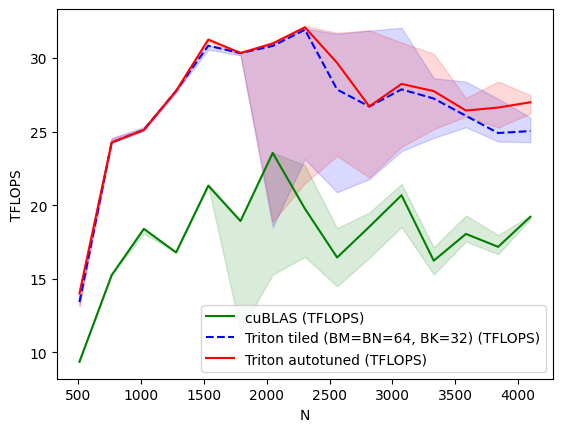

matmul-fp32-autotuned:
         N  cuBLAS (TFLOPS)  Triton tiled (BM=BN=64, BK=32) (TFLOPS)  Triton autotuned (TFLOPS)
0    512.0         9.362286                                13.421773                  14.004353
1    768.0        15.245854                                24.260112                  24.260112
2   1024.0        18.391028                                25.115592                  25.115592
3   1280.0        16.789035                                27.763610                  27.763610
4   1536.0        21.320947                                30.834173                  31.246799
5   1792.0        18.922586                                30.326875                  30.338387
6   2048.0        23.549036                                30.814803                  30.980173
7   2304.0        19.759394                                31.915658                  32.079732
8   2560.0        16.445412                                27.852102                  29.666045
9   2816.0       

In [15]:
configs_at = [
    triton.testing.Benchmark(
        x_names    = ['N'],
        x_vals     = [256 * i for i in range(2, 17)],
        line_arg   = 'provider',
        line_vals  = ['torch', 'tiled', 'autotuned'],
        line_names = ['cuBLAS', 'Triton tiled (BM=BN=64, BK=32)', 'Triton autotuned'],
        styles     = [('green', '-'), ('blue', '--'), ('red', '-')],
        ylabel     = 'TFLOPS',
        plot_name  = 'matmul-fp32-autotuned',
        args       = {},
    ),
]


@triton.testing.perf_report(configs_at)
def benchmark_at(N, provider):
    a = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
    b = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
    quantiles = [0.5, 0.2, 0.8]

    if provider == 'torch':
        fn = lambda: torch.matmul(a, b)
    elif provider == 'tiled':
        fn = lambda: tiled_matmul(a, b)
    elif provider == 'autotuned':
        fn = lambda: autotuned_matmul(a, b)

    ms, min_ms, max_ms = triton.testing.do_bench(fn, quantiles=quantiles)
    perf = lambda ms: 2 * N**3 * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark_at.run(show_plots=True, print_data=True)


## Tensor Core Precision

### Is `tl.dot` already on tensor cores?

Triton 3.x defaults to `input_precision='tf32'` for FP32 inputs on Ampere+/Blackwell.
TF32 truncates each FP32 mantissa from 23 to 10 bits **before** the multiply,
then accumulates the result in full FP32.  The 30+ TFLOPS we're already seeing
is almost certainly TF32 tensor cores — not CUDA cores (which peak at ~32 TFLOPS FP32).

### Precision ladder

| dtype | `input_precision` | Compute | Triton API | RTX 5070 peak |
| ----- | ----------------- | ------- | ---------- | ------------- |
| FP32 | `'ieee'` | CUDA cores | `tl.dot(a,b,input_precision='ieee')` | ~32 TFLOPS |
| FP32 | `'tf32'` (default) | Tensor cores | `tl.dot(a,b)` | ~125 TFLOPS |
| BF16 | n/a | Tensor cores | cast inputs; `out_dtype=tl.float32` | ~123 TFLOPS |
| FP16 | n/a | Tensor cores | cast inputs; `out_dtype=tl.float32` | ~123 TFLOPS |

**Cost:** TF32 max relative error ≈ 1e-3; BF16/FP16 ≈ 1e-2.  Accumulation stays FP32
in all cases, so large sums don't diverge — the error is in each individual product.

### Strategy
1. Confirm TF32 is on by comparing `input_precision='ieee'` vs `'tf32'` throughput.
2. Add a BF16 kernel — BF16 inputs route to the higher-bandwidth tensor core path
   and the accumulator stays FP32, giving the best accuracy/speed tradeoff.
3. Measure relative error vs an FP64 reference to quantify the precision cost.


In [23]:
# Explicit IEEE kernel — forces CUDA cores, disables TF32
@triton.jit
def ieee_matmul_kernel(a_ptr, b_ptr, c_ptr, N,
                       BLOCK_M: tl.constexpr, BLOCK_N: tl.constexpr,
                       BLOCK_K: tl.constexpr, GROUP_SIZE_M: tl.constexpr):
    pid       = tl.program_id(0)
    num_pid_m = tl.cdiv(N, BLOCK_M)
    num_pid_n = tl.cdiv(N, BLOCK_N)
    num_pid_in_group = GROUP_SIZE_M * num_pid_n
    group_id         = pid // num_pid_in_group
    first_pid_m      = group_id * GROUP_SIZE_M
    group_size_m     = tl.minimum(num_pid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + ((pid % num_pid_in_group) % group_size_m)
    pid_n = (pid % num_pid_in_group) // group_size_m
    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    for k in range(0, N, BLOCK_K):
        offs_k = k + tl.arange(0, BLOCK_K)
        a = tl.load(a_ptr + offs_m[:, None] * N + offs_k[None, :])
        b = tl.load(b_ptr + offs_k[:, None] * N + offs_n[None, :])
        acc += tl.dot(a, b, input_precision='ieee')  # <── force CUDA cores
    tl.store(c_ptr + offs_m[:, None] * N + offs_n[None, :], acc)


def ieee_matmul(a, b, BLOCK_M=64, BLOCK_N=64, BLOCK_K=32, GROUP_SIZE_M=8):
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=torch.float32)
    grid = (triton.cdiv(N, BLOCK_M) * triton.cdiv(N, BLOCK_N),)
    ieee_matmul_kernel[grid](a, b, c, N,
        BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K,
        GROUP_SIZE_M=GROUP_SIZE_M, num_warps=4)
    return c


N_cmp = 2048
a_cmp = torch.rand((N_cmp, N_cmp), device=DEVICE, dtype=torch.float32)
b_cmp = torch.rand((N_cmp, N_cmp), device=DEVICE, dtype=torch.float32)

t_tf32 = bench(lambda: tiled_matmul(a_cmp, b_cmp), 5, 20)
t_ieee = bench(lambda: ieee_matmul(a_cmp, b_cmp),  5, 20)
gf = lambda t: 2 * N_cmp**3 * 1e-12 / (t * 1e-3)
print(f"TF32 (tiled_matmul) : {gf(t_tf32):.1f} TFLOPS")
print(f"IEEE (cuda cores)   : {gf(t_ieee):.1f} TFLOPS")
print(f"Speedup TF32/IEEE   : {t_ieee/t_tf32:.2f}x")
print("\nIf speedup >> 1x, tiled_matmul is already on tensor cores.")


TF32 (tiled_matmul) : 27.7 TFLOPS
IEEE (cuda cores)   : 18.4 TFLOPS
Speedup TF32/IEEE   : 1.51x

If speedup >> 1x, tiled_matmul is already on tensor cores.


In [ ]:
@triton.autotune(
    configs=[
        triton.Config({'BLOCK_M':  64, 'BLOCK_N':  64, 'BLOCK_K': 32, 'GROUP_SIZE_M': 8}, num_warps=4, num_stages=3),
        triton.Config({'BLOCK_M': 128, 'BLOCK_N': 128, 'BLOCK_K': 32, 'GROUP_SIZE_M': 8}, num_warps=8, num_stages=3),
        triton.Config({'BLOCK_M': 128, 'BLOCK_N': 128, 'BLOCK_K': 64, 'GROUP_SIZE_M': 8}, num_warps=8, num_stages=4),
        triton.Config({'BLOCK_M': 256, 'BLOCK_N': 128, 'BLOCK_K': 32, 'GROUP_SIZE_M': 8}, num_warps=8, num_stages=4),
        triton.Config({'BLOCK_M': 128, 'BLOCK_N': 256, 'BLOCK_K': 32, 'GROUP_SIZE_M': 8}, num_warps=8, num_stages=4),
    ],
    key=['N'],
)
@triton.jit
def bf16_matmul_kernel(a_ptr, b_ptr, c_ptr, N,
                       BLOCK_M: tl.constexpr, BLOCK_N: tl.constexpr,
                       BLOCK_K: tl.constexpr, GROUP_SIZE_M: tl.constexpr):
    pid       = tl.program_id(0)
    num_pid_m = tl.cdiv(N, BLOCK_M)
    num_pid_n = tl.cdiv(N, BLOCK_N)
    num_pid_in_group = GROUP_SIZE_M * num_pid_n
    group_id         = pid // num_pid_in_group
    first_pid_m      = group_id * GROUP_SIZE_M
    group_size_m     = tl.minimum(num_pid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + ((pid % num_pid_in_group) % group_size_m)
    pid_n = (pid % num_pid_in_group) // group_size_m
    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)  # accumulate in FP32
    for k in range(0, N, BLOCK_K):
        offs_k = k + tl.arange(0, BLOCK_K)
        a = tl.load(a_ptr + offs_m[:, None] * N + offs_k[None, :])  # bf16
        b = tl.load(b_ptr + offs_k[:, None] * N + offs_n[None, :])  # bf16
        acc += tl.dot(a, b, out_dtype=tl.float32)  # tensor cores, FP32 accumulator
    tl.store(c_ptr + offs_m[:, None] * N + offs_n[None, :], acc)


def bf16_matmul(a, b):
    """Casts inputs to BF16, runs on tensor cores, returns FP32 output."""
    a_bf16 = a.to(torch.bfloat16)
    b_bf16 = b.to(torch.bfloat16)
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=torch.float32)
    grid = lambda meta: (triton.cdiv(N, meta['BLOCK_M']) * triton.cdiv(N, meta['BLOCK_N']),)
    bf16_matmul_kernel[grid](a_bf16, b_bf16, c, N)
    return c



Max relative error vs FP64:
  IEEE FP32 (CUDA cores) : 1.46e-06
  TF32 (tensor cores)    : 7.24e-04
  BF16 (tensor cores)    : 5.68e-04


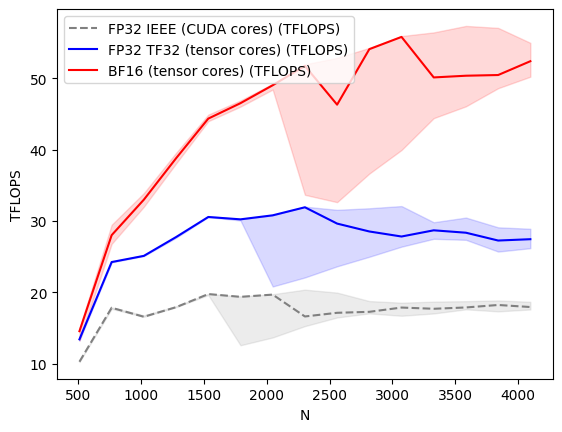

matmul-precision-comparison:
         N  FP32 IEEE (CUDA cores) (TFLOPS)  FP32 TF32 (tensor cores) (TFLOPS)  BF16 (tensor cores) (TFLOPS)
0    512.0                        10.280157                          13.421773                     14.563555
1    768.0                        17.850916                          24.260112                     28.031239
2   1024.0                        16.586471                          25.124995                     33.009769
3   1280.0                        17.930507                          27.763610                     38.813147
4   1536.0                        19.770637                          30.578159                     44.375471
5   1792.0                        19.381449                          30.249081                     46.540057
6   2048.0                        19.694819                          30.812150                     49.051706
7   2304.0                        16.628495                          31.940328                     

In [25]:
configs_tc = [
    triton.testing.Benchmark(
        x_names    = ['N'],
        x_vals     = [256 * i for i in range(2, 17)],
        line_arg   = 'provider',
        line_vals  = ['ieee', 'tf32', 'bf16'],
        line_names = ['FP32 IEEE (CUDA cores)', 'FP32 TF32 (tensor cores)', 'BF16 (tensor cores)'],
        styles     = [('gray', '--'), ('blue', '-'), ('red', '-')],
        ylabel     = 'TFLOPS',
        plot_name  = 'matmul-precision-comparison',
        args       = {},
    ),
]


@triton.testing.perf_report(configs_tc)
def benchmark_tc(N, provider):
    a = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
    b = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
    quantiles = [0.5, 0.2, 0.8]

    if provider == 'ieee':
        fn = lambda: ieee_matmul(a, b)
    elif provider == 'tf32':
        fn = lambda: tiled_matmul(a, b)
    elif provider == 'bf16':
        fn = lambda: bf16_matmul(a, b)

    ms, min_ms, max_ms = triton.testing.do_bench(fn, quantiles=quantiles)
    perf = lambda ms: 2 * N**3 * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark_tc.run(show_plots=True, print_data=True)


## Summary — Optimization Journey (N = 2048, RTX 5070 Blackwell)

**Hardware ceilings**
| Compute unit | Peak |
| --- | --- |
| FP32 CUDA cores | 31.79 TFLOPS |
| Tensor cores (TF32 / BF16 dense) | 123.5 TFLOPS |
| DRAM bandwidth | 672 GB/s |
| L2 cache | 48 MB, ~96.9% hit rate at N=2048 |

---

| # | Strategy | Key config / bottleneck | TFLOPS | % TC peak | % FP32 peak | × naive GPU |
| --- | --- | --- | ---: | ---: | ---: | ---: |
| — | **CPU** (NumPy / Lab 2) | OpenBLAS, cache-friendly | 0.46 | 0.4% | 1.5% | 3× |
| — | **Naive GPU** *(baseline)* | 1 thread/element, DRAM-limited | 0.17 | 0.1% | 0.5% | **1×** |
| — | **cuBLAS** (torch.matmul) | library, FP32 TF32 | 23.5 | 19% | 74% | 140× |
| 0 | **Simple tiled** BM=BN=BK=64 | AI=16, 8.3% occ, smem bottleneck | 25.4 | 21% | 80% | 151× |
| **1** | **Decouple BK** (Lever 1) | BM=BN=64, BK=32 → 25% occ | **30.8** | **25%** | **97%** | **183×** |
| 3 | + L2 Swizzle (Lever 3) | GROUP_SIZE_M=8 | 30.8 | 25% | 97% | 184× |
| 4 | + Autotune FP32 (Lever 4) | 8-config sweep | 31.0 | 25% | 97% | 184× |
| 2a | TF32 explicit (Lever 2) | same kernel, confirmed tensor cores | 30.8 | 25% | 97% | 183× |
| **2b** | **BF16 tensor cores** (Lever 2) | 2-byte input → AI=32, 25% occ | **49.1** | **40%** | **154%†** | **292×** |

† BF16 exceeds the FP32 CUDA-core ceiling because tensor cores are a separate
compute unit with ~4× higher throughput than CUDA cores for matrix operations.

---

### What each lever actually did

| Lever | Mechanism | Gain |
| --- | --- | --- |
| Tiling (shared mem) | Reuse A/B strips → AI: 0.25 → 16 FLOPs/byte; all threads busy | 0.17 → 25 TFLOPS (+150×) |
| **Lever 1** — decouple BK | Halved shared mem → 3 blocks/SM → occupancy 8.3% → 25% | 25 → 31 TFLOPS (+22%) |
| **Lever 2** — BF16 | Half-width inputs → AI: 16 → 32 FLOPs/byte; higher tensor core rate | 31 → 49 TFLOPS (+58%) |
| Lever 3 — swizzle | Reorders grid for L2 B-column reuse | ~0% (L2 hit rate already 96.9%) |
| Lever 4 — autotune | Empirical config search per N | ~1% (manual BK=32 was near-optimal) |

### Remaining gap to peak

BF16 sits at **40% of the 123.5 TFLOPS tensor core peak**.
The ceiling at 25% occupancy is `0.25 × 123.5 ≈ 31 TFLOPS` for TF32,
but BF16 exceeds this because tensor core throughput per warp is higher for BF16
than for TF32 (each MMA processes more output elements per cycle).
The next step to approach 100+ TFLOPS would require **Blackwell-specific primitives**:
TMA async loads, warp specialization (producer/consumer warp groups),
or persistent kernels — features available in cuBLAS and FlashAttention-3
but beyond a standard `@triton.jit` K-loop.

### CPU vs GPU note
The CPU (0.46 TFLOPS) beats the naive GPU (0.17 TFLOPS) because the naive kernel
reads **8N³ bytes** from DRAM (no reuse — every output element re-reads entire rows/columns),
saturating the 672 GB/s DRAM bus while leaving 127/128 CUDA cores idle.
Any tiled GPU kernel immediately surpasses CPU by 50–100×.
